#  Calculation of features from available libraries

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
dataset = 'Fe-Mo'# 'Fe-Mo'  # 'Cr-Co-W' # 
components = dataset.split('-')
system=dataset.replace('-','')
from  dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer

import Tools.DatasetTools.GeneralFeaturizer as gf

BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))

In [3]:
AtomsObjects = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR-initial-rescaled-AtomsObjects.pkl')).dropna()

PymatgenStructures = pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR-initial-rescaled-PymatgenStructures.pkl')).dropna()
SublatticeTags = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SUBLATICETAGS.pkl'))
SublatticeSorters = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SORTERS.pkl'))
SublatticeSorters.index = SublatticeSorters.index.str.strip()
SublatticeTags.index = SublatticeSorters.index.str.strip()

BS.dropna(inplace=True)

import numpy as np

descriptorslocation = os.path.join(dataset, 'Descriptors')

In [4]:
from Tools.DatasetTools.GeneralFeaturizer import cn_persite

# Prepare Extra features

In [5]:
from importlib.machinery import SourceFileLoader

In [6]:
from sklearn.preprocessing import  OneHotEncoder, LabelEncoder
encoder = LabelEncoder()

In [7]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer

In [8]:
Features = Featurizer(BS)

In [9]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

In [10]:
#DatasetFeatures = pd.concat((DatasetCompositionFeatures, DatasetMagneticFeature, StructureNameFeature), axis=1)

##  Magnetism and structure

In [11]:
StructureNameFeature = BS.Phase
StructureNameFeature.name='Structure'
encoder.fit(StructureNameFeature)
DatasetStructureFeature = pd.Series(encoder.transform(StructureNameFeature), name='Structure', index = StructureNameFeature.index)

In [12]:
MagneticFeature = Features.MagFeature
MagneticFeature.name = 'Mag'
encoder.fit(MagneticFeature)
DatasetMagneticFeature = pd.Series(encoder.transform(MagneticFeature), name='Mag', index = StructureNameFeature.index)

In [13]:
DatasetFeatures = pd.concat([DatasetMagneticFeature, DatasetStructureFeature, DatasetCompositionFeatures, BS.num_atoms], axis = 1)

## Coordination Polyhedra feature

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CP $$

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [14]:
SortingFeatures = gf.sorting_feature(AtomsObjects, SublatticeSorters, SublatticeTags)
SortingFeatures.sorters = gf.correct_sortings_fromphases(AtomsObjects, BS.Phase, SortingFeatures.sorters)
SortingFeatures.sublatticetags = gf.correct_occupation_fromphases(BS.Phase, SortingFeatures.sublatticetags, AtomsObjects.atoms)
sampleinspecial = BS.Phase.map(lambda p: p in gf.specialphases)
empty = SortingFeatures.sublatticetags.map(lambda sublat: '' in sublat)
SortingFeatures.sublatticetags[empty] = ['A']
wrong = SortingFeatures.sublatticetags.map(lambda sublat: 'A' not in sublat) 
fixable = SortingFeatures.sublatticetags.loc[wrong].map(type) == np.ndarray #.map(np.unique)
CNList = gf.get_sitecn(BS.Phase, AtomsObjects.atoms, SortingFeatures.sorters)

  0%|          | 0/277 [00:00<?, ?it/s]

## Position Features

In [15]:
elements = np.unique(BS.filter(regex='^atom_').values.ravel())
ABOCC = pd.concat([BS.filter(regex='atom_'), Features.occupation], axis = 1)
ABOCC.rename(columns={ABOCC.columns[-1]: 'index'}, inplace=True)

In [16]:
Positions = {}
for index, item in ABOCC.iterrows():
    if item['index'] == '':
        thisposition = {index: [item[f'atom_A']]*len(np.unique(gf.cn_dict[BS.Phase[index]]))}
    else:
        thisposition = {index: [item[f'atom_{occ}'] for occ in item['index'] ]}
    Positions.update(thisposition)
    

In [17]:
Positions = pd.DataFrame.from_dict(Positions, orient='index')
Positions[Positions.isnull()] = 0
for i, element in enumerate(elements):
    Positions[Positions==element] = i
Positions.columns = [f'Pos_{col+1}' for col in Positions.columns]
#Positions[Positions.Pos_1.map(type) == str] = np.nan

## Averages over Coordination polyhedra

### Number of each CP in each structure

In [18]:
CN = gf.featurize_series(CNList, CNList, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

### Composition and volume of the CP

In [19]:
from mendeleev import element

In [20]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'
symbols = dataset.split('-')
volums = {symb: element(symb).atomic_volume for symb in symbols}

In [21]:
AtomicVolumes = AtomsObjects.atoms.map(lambda a: [volums[at] for at in a.get_chemical_symbols()])

In [22]:
CPVol = gf.featurize_series(AtomicVolumes, CNList, return0=False, normalization='NCP')
newcolumns = ['V'+col for col in CPVol.columns]
CPVol.columns =  newcolumns

In [23]:
CPComp = gf.featurize_series(AtomicNumbers, CNList, return0=False, normalization='NCP')
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

## Compile all the descriptors

In [24]:
DatasetFeatures = pd.concat([DatasetStructureFeature, DatasetMagneticFeature, DatasetCompositionFeatures, CN, CPVol, CPComp, BS.num_atoms, Positions], axis=1)
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')
CNListlocation = os.path.join(dataset, 'Descriptors', 'CNList.pkl')
DatasetFeatures.to_pickle(datasetfeatureslocation)
CNList.to_pickle(CNListlocation)

In [25]:
BS['atoms_objects'] = PymatgenStructures

# ACE Features 

In [26]:
from ase.atoms import Atoms

In [27]:
def reset_symbols(a: Atoms, newsym : str = 'W'):
    newa = a.copy()
    natoms = newa.get_global_number_of_atoms()
    newsymbols = [newsym]*natoms
    newa.set_chemical_symbols(newsymbols)
    return newa

In [28]:
from importlib.machinery import SourceFileLoader

In [29]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator 
from Tools.DatasetTools.ACEDescriptors import default_options_dict as default_options_dict
from pyace import ACEBBasisSet, PyACECalculator

In [30]:
AceConfig = copy.copy(default_options_dict)

In [31]:
AceConfig['elements'] = dataset.split('-')

In [32]:
ACEer = MyPyACECalculator(components = components, multispace_basis_config = AceConfig)

In [33]:
ACEFEATURES = AtomsObjects['atoms'].map(ACEer.get_ace_projections)
ACEFEATURES.name = 'ace_projections'

In [34]:
expand_ace = gf.array_expansions(ACEFEATURES.to_frame(),['ace_projections']) 

In [35]:
CNAV_ACE = gf.featurize_dataframe(expand_ace, CNList)

In [36]:
CNAV_ACE

,ace_projections_0_0,ace_projections_0_CN12,ace_projections_0_CN13,ace_projections_0_CN14,ace_projections_0_CN15,ace_projections_0_CN16,ace_projections_1_0,ace_projections_1_CN12,ace_projections_1_CN13,ace_projections_1_CN14,...,ace_projections_298_CN13,ace_projections_298_CN14,ace_projections_298_CN15,ace_projections_298_CN16,ace_projections_299_0,ace_projections_299_CN12,ace_projections_299_CN13,ace_projections_299_CN14,ace_projections_299_CN15,ace_projections_299_CN16
Fe_pv8.A15.FM,5.560009,1.390275,0.000000,4.169734,0.000000,0.000000,5.311974,1.329134,0.000000,3.982840,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
Fe_pv12.C14.FM,5.559091,3.702394,0.000000,0.000000,0.000000,1.856697,5.300286,3.497891,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
Fe_pv24Mo_sv5.chi-BBAA.FM,4.318758,1.731424,1.804014,0.000000,0.000000,0.783320,4.184725,1.824858,1.648105,0.000000,...,1.000497,0.0,0.0,0.208359,0.716818,0.479830,0.198040,0.0,0.0,0.038948
Fe_pv25Mo_sv4.chi-ABAA.FM,4.555028,1.849298,1.879641,0.000000,0.000000,0.826090,4.403757,1.876022,1.790249,0.000000,...,0.581265,0.0,0.0,0.142962,0.270635,0.145096,0.095424,0.0,0.0,0.030116
Fe_pv30.sigma.FM,5.559784,1.852193,0.000000,2.965188,0.742403,0.000000,5.308828,1.752612,0.000000,2.841482,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,4.555028,1.849298,1.879641,0.000000,0.000000,0.826090,4.403757,1.876022,1.790249,0.000000,...,0.581265,0.0,0.0,0.142962,0.270635,0.145096,0.095424,0.0,0.0,0.030116
Fe_pv16Mo_sv8.C36-BBAAA.NM,3.281111,2.079644,0.000000,0.000000,0.000000,1.201467,3.163752,2.112955,0.000000,0.000000,...,0.000000,0.0,0.0,3.806646,14.089992,12.680944,0.000000,0.0,0.0,1.409048
Fe_pv8Mo_sv4.C14-BAA.NM,3.281388,2.080452,0.000000,0.000000,0.000000,1.200937,3.161834,2.108110,0.000000,0.000000,...,0.000000,0.0,0.0,3.838258,14.070840,12.646393,0.000000,0.0,0.0,1.424447
Fe_pv4.fcc-cubic.NM,5.562771,5.562771,0.000000,0.000000,0.000000,0.000000,5.324237,5.324237,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000


In [37]:
selection = CNAV_ACE[Features.StrucNames == 'bcc'].filter(regex='_0$')

In [38]:
selection

,ace_projections_0_0,ace_projections_1_0,ace_projections_2_0,ace_projections_3_0,ace_projections_4_0,ace_projections_5_0,ace_projections_6_0,ace_projections_7_0,ace_projections_8_0,ace_projections_9_0,...,ace_projections_290_0,ace_projections_291_0,ace_projections_292_0,ace_projections_293_0,ace_projections_294_0,ace_projections_295_0,ace_projections_296_0,ace_projections_297_0,ace_projections_298_0,ace_projections_299_0
Fe_pv2.bcc-cubic.FM,5.561434,5.31806,2.78563,4.320881,1.476867,-2.705836,1.71095,5.201591,3.179378,5.275408,...,0.0,0.000000,0.000000e+00,0.000000e+00,5320.274558,0.0,0.0,0.0,0.0,0.000000
Mo_sv1.bcc.FM,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.0,256.079032,-1.396226e-31,7.612672e-65,0.000000,0.0,0.0,0.0,0.0,1024.395173
Mo_sv1.bcc.NM,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.0,256.079032,-1.396226e-31,7.612672e-65,0.000000,0.0,0.0,0.0,0.0,1024.395173
Fe_pv1.bcc.NM,5.561434,5.31806,2.78563,4.320881,1.476867,-2.705836,1.71095,5.201591,3.179378,5.275408,...,0.0,0.000000,0.000000e+00,0.000000e+00,5320.274558,0.0,0.0,0.0,0.0,0.000000


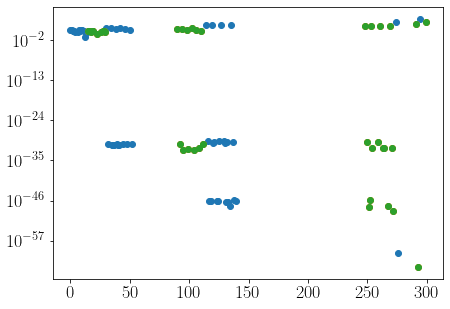

In [39]:
fig, ax = plt.subplots()
ax.plot(selection.iloc[0].values, 'o')
ax.plot(selection.iloc[1].values, 'o')
ax.plot(selection.iloc[2].values, 'o')
ax.set_yscale('log')

In [40]:
ACE_file = os.path.join(descriptorslocation, f'{dataset}-ACE-CNAV.pkl')

CNAV_ACE.to_pickle(ACE_file)

# Prepare for prediction

In [53]:
R_structures_file = os.path.join(dataset, 'Atomsobjects', 'R_structures.pkl')

In [56]:
if os.path.exists(R_structures_file):
    R_structures = pd.read_pickle(R_structures_file)
    if not R_structures.index.str.contains('.NM$').any():
        R_structures.index += '.NM'
else:
    import warnings
    warnings.warn(" R structures for prediction have not been created. execute notebook 9")

UserWarning:  R structures for prediction have not been created. execute notebook 9

In [55]:
R_structures

NameError: name 'R_structures' is not defined

In [81]:
acer = MyPyACECalculator(components, multispace_basis_config=AceConfig)

In [82]:
import tracemalloc

In [83]:
ACE_R_file = os.path.join(descriptorslocation, 'ACE_R_full.pkl')

In [84]:
tracemalloc.start()

In [47]:
if os.path.exists(ACE_R_file):
    ACE_R = pd.read_pickle(ACE_R_file)
else:
    ACE_R = {}

In [87]:
ACE_R = {}

In [88]:
progress = tqdm(R_structures.atoms.items(), total = len(R_structures))
for index, atoms in progress: 
    if index in ACE_R.keys():
        continue
    ACE_R[index] = acer.get_ace_projections(atoms)
    memory = tracemalloc.get_traced_memory()[0]/1024/1024
    progress.set_postfix_str(f'{memory:.2f} MB')
tracemalloc.stop()

  0%|          | 0/2048 [00:00<?, ?it/s]

In [90]:
if not isinstance(ACE_R, pd.core.series.Series):
    ACE_R = pd.Series(ACE_R)
    ACE_R.name = 'ace_projections'
ACE_R.to_pickle(ACE_R_file)

In [98]:
ACE_R.name = 'ace_projections'

In [99]:
CNList_Rs = pd.Series([cn_persite['R']]*len(R_structures), index=R_structures.index)

In [100]:
expand_ACE_R =gf.array_expansions( ACE_R.to_frame(), ['ace_projections'])

In [101]:
CNAV_ACE_R = gf.featurize_dataframe(expand_ACE_R, CNList_Rs)

In [102]:
CNAV_ACE_R_file = os.path.join(descriptorslocation, f'{dataset}-ACE-CNAV-Rs.pkl')

In [105]:
CNAV_ACE_R.to_pickle(CNAV_ACE_R_file)

In [104]:
CNAV_ACE_R

,ace_projections_1_0,ace_projections_1_CN12,ace_projections_1_CN13,ace_projections_1_CN14,ace_projections_1_CN15,ace_projections_1_CN16,ace_projections_2_0,ace_projections_2_CN12,ace_projections_2_CN13,ace_projections_2_CN14,...,ace_projections_298_CN13,ace_projections_298_CN14,ace_projections_298_CN15,ace_projections_298_CN16,ace_projections_299_0,ace_projections_299_CN12,ace_projections_299_CN13,ace_projections_299_CN14,ace_projections_299_CN15,ace_projections_299_CN16
Fe_pv53.R-AAAAAAAAAAA.NM,5.399523,2.712258,0.0,1.234667,0.619030,0.833569,2.883521,1.568297,0.0,0.632353,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000e+00,0.000000,0.000000
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,4.723417,2.391105,0.0,1.076124,0.527693,0.728494,2.555320,1.495262,0.0,0.524894,...,0.0,0.082081,0.050049,0.168800,0.184761,0.138132,0.0,8.935591e-03,0.005328,0.032365
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,5.171806,2.604056,0.0,1.186108,0.584135,0.797507,2.775573,1.562451,0.0,0.571394,...,0.0,0.000056,0.000131,0.006898,0.002856,0.002445,0.0,8.547904e-07,0.000003,0.000408
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,4.500252,2.284077,0.0,1.029431,0.493889,0.692855,2.450703,1.490684,0.0,0.465537,...,0.0,0.139623,0.104357,0.481764,0.855376,0.715176,0.0,1.779554e-02,0.013819,0.108585
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,4.728912,2.388081,0.0,1.074447,0.558648,0.707736,2.544155,1.436429,0.0,0.583767,...,0.0,0.340300,0.029141,0.052797,0.162913,0.100620,0.0,5.409055e-02,0.002664,0.005538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,0.574706,0.278445,0.0,0.139380,0.051083,0.105798,0.269789,0.096064,0.0,0.029918,...,0.0,59.938096,24.680854,31.685031,1975.768385,960.739098,0.0,4.012063e+02,270.158240,343.664698
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,0.776488,0.376642,0.0,0.170118,0.106342,0.123386,0.342033,0.035692,0.0,0.138104,...,0.0,53.027673,29.886501,42.081204,1679.485931,711.764480,0.0,4.922040e+02,234.154435,241.363016
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,0.193060,0.095526,0.0,0.036338,0.027970,0.033226,0.082313,-0.005107,0.0,0.050481,...,0.0,9.035637,7.037841,21.918057,2864.919802,1379.628216,0.0,7.290243e+02,364.990334,391.276963
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,0.579972,0.280374,0.0,0.132328,0.077460,0.089809,0.257241,0.040122,0.0,0.086317,...,0.0,47.972586,26.474258,33.115887,1998.939770,905.005830,0.0,5.161180e+02,255.465390,322.350589


## ACE no zero

In [53]:
components

['Fe', 'Mo']

In [54]:
nozero_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[0])

In [55]:
all_funcspecs = []
for block in nozero_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs.append(spec) for spec in block.funcspecs]
    

In [56]:
all_funcspecs

[BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,1],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,1],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,1],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,2],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,2],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,2],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,3],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,3],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,3],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[2,2],  ls=[1,1],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[2,2],  ls=[2,2],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=

In [57]:
len(all_funcspecs)

258

In [58]:
NOZEROACEFEATURES = AtomsObjects['atoms'].map(nozero_acer.get_ace_projections)
NOZEROACEFEATURES.name = 'light_ace_projections'

In [59]:
expand_NOZEROACEFEATURES = gf.array_expansions(NOZEROACEFEATURES.to_frame(), ['light_ace_projections'])

In [60]:
CNAV_NOZEROACEFEATURES = gf.featurize_dataframe(expand_NOZEROACEFEATURES, CNList)

In [64]:
CNList[CNList.index.str.contains('.NM$')]

Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 1...
Fe_pv1Mo_sv3.D03-AB3.NM                                             [14, 14, 14, 14]
Fe_pv6Mo_sv18.C36-BBBBA.NM         [12, 12, 12, 12, 12, 12, 16, 16, 16, 16, 16, 1...
Fe_pv2Mo_sv11.mu-BBABB.NM          [15, 15, 12, 12, 12, 12, 12, 12, 12, 16, 16, 1...
Fe_pv2Mo_sv11.mu-BBBAB.NM          [16, 16, 12, 12, 12, 12, 12, 12, 12, 15, 15, 1...
                                                         ...                        
Fe_pv5Mo_sv24.chi-AABB.NM          [16, 16, 16, 16, 16, 13, 13, 13, 13, 13, 13, 1...
Fe_pv6Mo_sv18.C36-BBBAB.NM         [12, 12, 12, 12, 12, 12, 16, 16, 16, 16, 16, 1...
Fe_pv3Mo_sv10.mu-ABBBA.NM          [12, 14, 14, 12, 12, 12, 12, 12, 12, 15, 15, 1...
Fe_pv8Mo_sv22.sigma-BBABB.NM       [14, 14, 14, 14, 14, 14, 14, 14, 12, 12, 15, 1...
Fe_pv10Mo_sv20.sigma-ABBAB.NM      [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 15, 1...
Length: 150, dtype: object

In [61]:
CNAV_NOZEROACEFEATURES.shape

(252, 768)

In [62]:
CNAV_ACE.shape

(252, 1794)

In [ ]:
NOZERO_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOZERO-ACE-CNAV.pkl')

CNAV_NOZEROACEFEATURES.to_pickle(NOZERO_ACE_file)

## NOZERO NOONE ACE

In [ ]:
nozero_noone_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[0,1])

In [ ]:
all_funcspecs_nozeronoone = []
for block in nozero_noone_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nozeronoone.append(spec) for spec in block.funcspecs]
    

In [ ]:
nozero_noone_acer.bbasis_configuration

In [ ]:
all_funcspecs_nozeronoone

In [ ]:
NOZERO_NOONE_ACEFEATURES = AtomsObjects['atoms'].map(nozero_noone_acer.get_ace_projections)
NOZERO_NOONE_ACEFEATURES.name = 'light_ace_projections'

In [ ]:
expand_NOZERO_NOONE_ACEFEATURES = gf.array_expansions(NOZERO_NOONE_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [ ]:
expand

In [68]:
CNAV_NOZERO_NOONE_CEFEATURES = gf.featurize_dataframe(expand_NOZERO_NOONE_ACEFEATURES, CNList)

In [69]:
CNAV_NOZERO_NOONE_CEFEATURES.shape

(252, 366)

In [70]:
CNAV_ACE.shape

(252, 1794)

In [71]:
NOZERO_NOONE_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOZERO_NOONE-ACE-CNAV.pkl')

CNAV_NOZERO_NOONE_CEFEATURES.to_pickle(NOZERO_NOONE_ACE_file)

## NOZERO NOONE NOTWO ACE

In [72]:
nozero_noone_notwo_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[0,1,2])

In [73]:
all_funcspecs_nozeronoonenotwo = []
for block in nozero_noone_notwo_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nozeronoonenotwo.append(spec) for spec in block.funcspecs]
    

In [74]:
nozero_noone_notwo_acer.bbasis_configuration

BBasisConfiguration(deltaSplineBins=0.001, funcspecs_blocks=['Fe', 'Mo', 'Fe Mo', 'Mo Fe', ])

In [75]:
all_funcspecs_nozeronoonenotwo

[BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,1],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,2],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[1,3],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[2,2],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[2,3],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Fe,Fe,Fe],  ns=[3,3],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Mo,Mo,Mo],  ns=[1,1],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Mo,Mo,Mo],  ns=[1,2],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Mo,Mo,Mo],  ns=[1,3],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Mo,Mo,Mo],  ns=[2,2],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Mo,Mo,Mo],  ns=[2,3],  ls=[3,3],  coeffs=[0]),
 BBasisFunctionSpecification(elements=[Mo,Mo,Mo],  ns=

In [62]:
NOZERO_NOONE_NOTWO_ACEFEATURES = AtomsObjects['atoms'].map(nozero_noone_notwo_acer.get_ace_projections)
NOZERO_NOONE_NOTWO_ACEFEATURES.name = 'light_ace_projections'

In [63]:
expand_NOZERO_NOONE_NOTWO_ACEFEATURES = gf.array_expansions(NOZERO_NOONE_NOTWO_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [64]:
CNAV_NOZERO_NOONE_NOTWO_CEFEATURES = gf.featurize_dataframe(expand_NOZERO_NOONE_NOTWO_ACEFEATURES, CNList)

In [65]:
CNAV_NOZERO_NOONE_NOTWO_CEFEATURES.shape

(252, 120)

In [66]:
CNAV_ACE.shape

(252, 1794)

In [67]:
NOZERO_NOONE_NOTWO_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOZERO_NOONE_NOTWO-ACE-CNAV.pkl')

CNAV_NOZERO_NOONE_CEFEATURES.to_pickle(NOZERO_NOONE_NOTWO_ACE_file)

## NOTHREE ACE

In [68]:
nothree_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[3])

In [69]:
all_funcspecs_nothree = []
for block in nothree_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nothree.append(spec) for spec in block.funcspecs]
    

In [70]:
nothree_acer.bbasis_configuration

BBasisConfiguration(deltaSplineBins=0.001, funcspecs_blocks=['Fe', 'Mo', 'Fe Mo', 'Mo Fe', ])

In [71]:
NOTHREE_ACEFEATURES = AtomsObjects['atoms'].map(nothree_acer.get_ace_projections)
NOTHREE_ACEFEATURES.name = 'light_ace_projections'

In [72]:
expand_NOTHREE_ACEFEATURES = gf.array_expansions(NOTHREE_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [73]:
CNAV_NOTHREE_ACEFEATURES = gf.featurize_dataframe(expand_NOTHREE_ACEFEATURES, CNList)

In [74]:
CNAV_NOTHREE_ACEFEATURES.shape

(252, 1668)

In [75]:
CNAV_ACE.shape

(252, 1794)

In [76]:
NOTHREE_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOTHREE-ACE-CNAV.pkl')

CNAV_NOTHREE_ACEFEATURES.to_pickle(NOTHREE_ACE_file)

## NOTHREE NOTWO ACE

In [77]:
nothree_notwo_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[2,3])

In [78]:
all_funcspecs_nothree_notwo = []
for block in nothree_notwo_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nothree_notwo.append(spec) for spec in block.funcspecs]
    

In [79]:
nothree_notwo_acer.bbasis_configuration

BBasisConfiguration(deltaSplineBins=0.001, funcspecs_blocks=['Fe', 'Mo', 'Fe Mo', 'Mo Fe', ])

In [80]:
NOTHREE_NOTWO_ACEFEATURES = AtomsObjects['atoms'].map(nothree_notwo_acer.get_ace_projections)
NOTHREE_NOTWO_ACEFEATURES.name = 'light_ace_projections'

In [81]:
expand_NOTHREE_NOTWO_ACEFEATURES = gf.array_expansions(NOTHREE_NOTWO_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [82]:
CNAV_NOTHREE_NOTWO_ACEFEATURES = gf.featurize_dataframe(expand_NOTHREE_NOTWO_ACEFEATURES, CNList)

In [83]:
CNAV_NOTHREE_NOTWO_ACEFEATURES.shape

(252, 942)

In [84]:
CNAV_ACE.shape

(252, 1794)

In [85]:
NOTHREE_NOTWO_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOTHREE_NOTWO-ACE-CNAV.pkl')

CNAV_NOTHREE_NOTWO_ACEFEATURES.to_pickle(NOTHREE_NOTWO_ACE_file)

## NOTHREE NOTWO NOONE ACE

In [86]:
nothree_notwo_noone_acer = MyPyACECalculator(components, multispace_basis_config=AceConfig, exclude_ls=[1,2,3])

In [87]:
all_funcspecs_nothree_notwo_noone = []
for block in nothree_notwo_noone_acer.new_bbasis.funcspecs_blocks:
    [all_funcspecs_nothree_notwo_noone.append(spec) for spec in block.funcspecs]
    

In [88]:
nothree_notwo_noone_acer.bbasis_configuration

BBasisConfiguration(deltaSplineBins=0.001, funcspecs_blocks=['Fe', 'Mo', 'Fe Mo', 'Mo Fe', ])

In [89]:
NOTHREE_NOTWO_NOONE_ACEFEATURES = AtomsObjects['atoms'].map(nothree_notwo_noone_acer.get_ace_projections)
NOTHREE_NOTWO_NOONE_ACEFEATURES.name = 'light_ace_projections'

In [90]:
expand_NOTHREE_NOTWO_NOONE_ACEFEATURES = gf.array_expansions(NOTHREE_NOTWO_NOONE_ACEFEATURES.to_frame(), ['light_ace_projections'])

In [91]:
CNAV_NOTHREE_NOTWO_NOONE_ACEFEATURES = gf.featurize_dataframe(expand_NOTHREE_NOTWO_NOONE_ACEFEATURES, CNList)

In [92]:
CNAV_NOTHREE_NOTWO_NOONE_ACEFEATURES.shape

(252, 486)

In [93]:
CNAV_ACE.shape

(252, 1794)

In [94]:
NOTHREE_NOTWO_NOONE_ACE_file = os.path.join(descriptorslocation, f'{dataset}-NOTHREE_NOTWO_NOONE-ACE-CNAV.pkl')

CNAV_NOTHREE_NOTWO_NOONE_ACEFEATURES.to_pickle(NOTHREE_NOTWO_NOONE_ACE_file)

## Canonical 

In [95]:
CanonicalAceConfig = copy.copy(AceConfig)

In [96]:
CanonicalAceConfig['elements'] = ['W']

In [97]:
CanonicalACEer = MyPyACECalculator(components = CanonicalAceConfig['elements'], multispace_basis_config=CanonicalAceConfig)

In [98]:
canonicalatomsobjects = AtomsObjects['atoms'].map(reset_symbols)

In [99]:
canonicalacedescriptors = canonicalatomsobjects.map(CanonicalACEer.get_ace_projections)
canonicalacedescriptors.name = 'canonical_ace_projections'

In [100]:
expand_canonical_ace = gf.array_expansions(canonicalacedescriptors.to_frame(),['canonical_ace_projections']) 

In [101]:
CNAV_CANONICAL_ACE = gf.featurize_dataframe(expand_canonical_ace, CNList)

In [102]:
CNAV_CANONICAL_ACE

,canonical_ace_projections_1_0,canonical_ace_projections_1_CN12,canonical_ace_projections_1_CN13,canonical_ace_projections_1_CN14,canonical_ace_projections_1_CN15,canonical_ace_projections_1_CN16,canonical_ace_projections_2_0,canonical_ace_projections_2_CN12,canonical_ace_projections_2_CN13,canonical_ace_projections_2_CN14,...,canonical_ace_projections_67_CN13,canonical_ace_projections_67_CN14,canonical_ace_projections_67_CN15,canonical_ace_projections_67_CN16,canonical_ace_projections_68_0,canonical_ace_projections_68_CN12,canonical_ace_projections_68_CN13,canonical_ace_projections_68_CN14,canonical_ace_projections_68_CN15,canonical_ace_projections_68_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,5.054865,1.665614,0.000000,2.706603,0.682648,0.000000,2.589041,0.917313,0.000000,1.372411,...,0.000000e+00,2.879043e-08,8.638313e-10,0.000000e+00,3897.199733,1294.963565,0.000000,2078.200378,524.035789,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,5.084335,1.675703,0.000000,2.722280,0.686352,0.000000,2.611098,0.925032,0.000000,1.384100,...,0.000000e+00,2.821184e-08,8.193052e-10,0.000000e+00,4044.081455,1343.795962,0.000000,2156.577090,543.708402,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,4.996157,3.291134,0.000000,0.000000,0.000000,1.705023,2.602889,1.933560,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,5.067541e-08,3681.458308,2441.120897,0.000000,0.000000,0.000000,1240.337411
Fe_pv5Mo_sv24.chi-AABB.FM,5.026349,2.073581,2.082899,0.000000,0.000000,0.869870,2.590202,1.122268,1.065443,0.000000,...,4.019403e-09,0.000000e+00,0.000000e+00,5.157614e-10,3707.783234,1528.045663,1540.593126,0.000000,0.000000,639.144444
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,5.057156,2.532920,0.000000,1.156932,0.582582,0.784721,2.625939,1.430445,0.000000,0.572427,...,0.000000e+00,5.083748e-06,1.910081e-06,4.379400e-07,3938.736571,2004.154888,0.000000,887.403161,458.899927,588.278595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,5.016459,2.637818,0.000000,0.786369,0.802306,0.789965,2.617196,1.554765,0.000000,0.372316,...,0.000000e+00,9.321128e-04,1.132177e-13,1.212006e-07,3857.617859,2122.412736,0.000000,541.220128,506.235817,687.749178
Fe_pv8Mo_sv22.sigma-BBABB.NM,5.054865,1.665614,0.000000,2.706603,0.682648,0.000000,2.589041,0.917313,0.000000,1.372411,...,0.000000e+00,2.879043e-08,8.638313e-10,0.000000e+00,3897.199733,1294.963565,0.000000,2078.200378,524.035789,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,5.065259,5.065259,0.000000,0.000000,0.000000,0.000000,2.616725,2.616725,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3874.207984,3874.207984,0.000000,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,5.054865,1.665614,0.000000,2.706603,0.682648,0.000000,2.589041,0.917313,0.000000,1.372411,...,0.000000e+00,2.879043e-08,8.638313e-10,0.000000e+00,3897.199733,1294.963565,0.000000,2078.200378,524.035789,0.000000


In [103]:
canonical_ACE_file = os.path.join(descriptorslocation, f'{dataset}-canonical-ACE-CNAV.pkl')

In [104]:
CNAV_CANONICAL_ACE.to_pickle(canonical_ACE_file)

In [105]:
from Tools.DatasetTools.ACEDescriptors import MyPyACECalculator
TestMyPyAce = SourceFileLoader('TestMyPyAce', 'Tools/DatasetTools/ACEDescriptors.py').load_module().TestMyPyAce
Test = TestMyPyAce()
Test.setUpClass()

# I think all the following happened in a conversation with Yuri:

``` python

In [106]:
new_multispace_config = copy.deepcopy(Test.default_multispace_config)
new_multispace_config['embeddings'] = {                                                                                  
     'Cr': {
         'npot': 'FinnisSinclairShiftedScaled',
         'fs_parameters': [1, 1], ## non-linear embedding function: 1*rho_1^1 + 1*rho_2^0.5
         'ndensity': 1,
         'rho_core_cut': 2000,
         'drho_core_cut': 250
         }, 

     'Co': {
         'npot': 'FinnisSinclairShiftedScaled', ## linear embedding function: 1*rho_1^1
         'fs_parameters': [1, 1],
         'ndensity': 1,
         'rho_core_cut': 3000,
         'drho_core_cut': 150
         }, 
    'W': {
         'npot': 'FinnisSinclairShiftedScaled', ## linear embedding function: 1*rho_1^1
         'fs_parameters': [1, 1],
         'ndensity': 1,
         'rho_core_cut': 3000,
         'drho_core_cut': 150
         }
     }
new_multispace_config['functions'] = {
                     'UNARY':  {
                             'nradmax_by_orders': [5, 1, 1, 1, 1],
                             'lmax_by_orders': [ 0, 3, 2,1,0],
                             },
#                      'Mo':  {
#                              'nradmax_by_orders': [5, 1, 1, 1, 1],
#                              'lmax_by_orders': [ 0, 3, 2,1,0],
#                              },
                     'BINARY':  {
                             'nradmax_by_orders': [5, 1, 1, 1, 1],
                             'lmax_by_orders': [ 0, 3, 2,1,0],
                             }
    }

# new_multispace_config['functions'] = {
#                      'ALL':  {
#                              'nradmax_by_orders': [5, 1, 1, 1, 1],
#                              'lmax_by_orders': [ 0, 3, 2,1,0],
#                              }
#     }

In [107]:
bas= construct_bbasisconfiguration(new_multispace_config)

bas.funcspecs_blocks[2].funcspecs

bas.funcspecs_blocks[2].funcspecs

construct_bbasisconfiguration??

Test.default_multispace_config

construct_bbasisconfiguration(Test.default_multispace_config)



ShorterFunctionsOptions = copy.deepcopy(default_options)

ShorterFunctionsOptions['functions'] = new_functions

ShorterFunctionsACE = MyPyACECalculator(components=['Fe','Mo'], multispace_basis_config=ShorterFunctionsOptions)

ACEFEATURES_shorter_functions = AtomsObjects['atoms'].map(ShorterFunctionsACE.get_ace_projections)
ACEFEATURES.name = 'ace_projections_shorter_functions'
```

SyntaxError: invalid syntax (1570712161.py, line 23)

# SOAPFeatures

In [ ]:
from dscribe.descriptors import SOAP
from mendeleev import element
import ase
from sklearn.feature_selection import VarianceThreshold

In [ ]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [ ]:
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

In [ ]:
soap_params = dict(rcut = 4, nmax = 9, lmax = 6, sigma = 0.1, rbf = 'gto', periodic = True, crossover = True)
params_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])

## Canonical

In [ ]:
def reset_symbols(a: ase.atoms.Atoms, newsym : str = 'W'):
    newa = a.copy()
    natoms = newa.get_global_number_of_atoms()
    newsymbols = [newsym]*natoms
    newa.set_chemical_symbols(newsymbols)
    return newa

In [ ]:
soapcases = ['canonicalW', 'specific']

In [ ]:
SOAPFEATURES = {}
EXPANDED_SOAP = {}
AVE_SOAP = {}
variances = {}
SEL_SOAP = {}
FINAL_SOAP = {}
soap_params = dict(rcut = 4, nmax = 9, lmax = 6, sigma = 0.1, rbf = 'gto', periodic = True, crossover = True)
params_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])
soap_features_file={}

In [ ]:
for soapcase in soapcases:
    print(soapcase)
    soap_features_file.update({soapcase: os.path.join(descriptorslocation, f'soap_features__{soapcase}__{params_str}.kpl')})
    if 'canonicalFe' in soapcase:
        species=[26]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: reset_symbols(a, 'Fe'))
    elif 'canonicalW' in soapcase:
        species=[74]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: reset_symbols(a, 'W'))
    elif 'specific' in soapcase:
        species = [element(s).atomic_number for s in dataset.split('-')]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: copy.deepcopy(a))
    SOAPER = SOAP(species=species, **soap_params)
    SOAPFEATURES.update({soapcase: thisatomsobjects.map(SOAPER.create)}) #,pd.DataFrame(data= columns=['SOAP'])
    EXPANDED_SOAP.update({soapcase: gf.array_expansions(SOAPFEATURES[soapcase].to_frame(name='SOAP'), ['SOAP'])})
    AVE_SOAP.update({soapcase: gf.featurize_dataframe(EXPANDED_SOAP[soapcase], CNList)})
    variances.update({soapcase: {name: col.var() for name, col in AVE_SOAP[soapcase].iteritems()}})
    selector = VarianceThreshold(threshold=1e-7)
    SEL_SOAP.update({soapcase: selector.fit_transform(AVE_SOAP[soapcase])})
    FINAL_SOAP.update({soapcase: pd.DataFrame(data=SEL_SOAP[soapcase], columns = selector.get_feature_names_out(), index=AVE_SOAP[soapcase].index)})
    FINAL_SOAP[soapcase].to_pickle(soap_features_file[soapcase])

In [ ]:
soap_features_file

# Pyscal features 

In [ ]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{system}-POSCAR-initial-rescaled-AtomsObjects.pkl')

In [ ]:
from tqdm.auto import tqdm
from Tools.DatasetTools import pyscalfeaturizers as pf
from BopFoxFeaturizer.struct_db import struct_db
AtomsObjects = pd.read_pickle(atomsobjectfile).dropna()

##  Coordination Numbers

In [ ]:
featurizers = [pf.pyscal_steinhardt, pf.pyscal_cn] #, get_steinhardt]
pyscal_features = [feature.__name__ for feature in featurizers]

pyscalsteinhardt = os.path.join(descriptorslocation, 'pyscal_steinhardt.kpl')

if os.path.exists(pyscalsteinhardt):
    PyscalFeatures = pd.read_pickle(pyscalsteinhardt)
else:
    PyscalFeatures = pf.featurize_many(AtomsObjects,  featurizers, colid='atoms')
    expanded_ste = pf.expand_features(PyscalFeatures.pyscal_steinhardt, 'pyscal_steinhardt')
    PyscalFeatures = pd.concat([expanded_ste, PyscalFeatures.pyscal_cn], axis=1)
    PyscalFeatures.to_pickle(pyscalsteinhardt)

In [ ]:
PyscalFeatures

## Stainhardt parameters 

From the Steinhardt parameters obtained by Pyscal library, we also want to average over the coordination polyhedra. This time we are also saving the total average for each parameter.

$$ q_{j, CP} ^i = \dfrac{1}{n_{at}^i}\sum _{at \in CP} q_{j, at} ^i $$

In [ ]:
thisFeatures = PyscalFeatures[['pyscal_steinhardt_0','pyscal_steinhardt_1']]

In [ ]:
intersect = thisFeatures.index.intersection(CNList.index)

In [ ]:
CNPyscal  = gf.featurize_many(thisFeatures.loc[intersect], CNList[intersect], [gf.cn_average])

In [ ]:
CNPyscal

In [ ]:
PyscalFeaturesFile = os.path.join(descriptorslocation,'CNAVPyscal.pkl')

In [ ]:
CNPyscal.to_pickle(PyscalFeaturesFile)

# Characterization of Features 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.pairplot(CN)

##  Correlations

In [ ]:
plt.rc('font',size=22)

In [ ]:
BS['EF'] = BS['EF'].astype(float)

In [ ]:
FeatureGroups = {'density features': DensitiFeatures, 'atomic features': AtomicFeaturesMagpie, 'composition features': CompositionFeatures, 'Dataset Features': DatasetFeatures}
TargetCorrelations = {groupname: GroupFeatures.corrwith(BS['EF']).abs().dropna().sort_values(ascending=False) for groupname, GroupFeatures in FeatureGroups.items()}

In [ ]:
len(TargetCorrelations)

In [ ]:
fig = plt.figure(figsize=(len(TargetCorrelations)*7, 10))
border=0
totalfeatures=18
for i, (group, TargetCorr) in enumerate(TargetCorrelations.items()):
    nfeatures = len(TargetCorr[:5])
    ax = fig.add_axes([border/totalfeatures,0.2,(nfeatures)/totalfeatures,0.7])
    border +=nfeatures
    ax.bar( TargetCorr[:5].index,TargetCorr[:5].values) #, ax = ax, orient='vertical')
axes = fig.get_axes()
# [tax.set_yticklabels(tax.get_yticklabels(), visible=False) for tax in axes[1:]]
[tax.sharey(axes[0]) for tax in axes[:1]]
#axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90) 

# Plot correlations for most correlated

In [ ]:
for name, item in DensitiFeatures.iteritems():
    print(name)

In [ ]:
DensitiFeatures[DensitiFeatures.vpa < 6]

In [ ]:
sns.histplot(DensitiFeatures.vpa)

In [ ]:
fig, axes = plt.subplots(1, 3, sharey = True, figsize=(15,5))
for (fname, feature), ax in zip(DensitiFeatures.iteritems(), axes):
    feature.hist(ax=ax)
#    sns.histplot(feature, ax =ax)

## By hand outlier detection:

In [ ]:
selection = (FeatureGroups['density features']['packing fraction'] < 3) & (FeatureGroups['density features']['vpa']>8) &(FeatureGroups['density features']['density']<75)

In [ ]:
def target_correlation_scatters(thisgroup, selection=None):
    featurenames = TargetCorrelations[thisgroup].index.to_list()
    if selection is None:
        selection = FeatureGroups[thisgroup].index
    nplots =  min([4, len(featurenames)])
    fig, axes = plt.subplots(1, nplots,  figsize=(7*4, 10), sharey=True)
    intersect = selection.intersection(BS['EF'].index)
    for ax, thisfeature in zip(axes, featurenames[:nplots]):
        ax.scatter(FeatureGroups[thisgroup][thisfeature][intersect], BS['EF'][intersect])
        ax.set_xlabel(thisfeature)
    axes[0].set_ylabel(r'$\Delta E_f$')

In [ ]:
target_correlation_scatters('atomic features')

In [ ]:
target_correlation_scatters('density features')#, selection=selection)

In [ ]:
target_correlation_scatters('composition features')

In [ ]:
target_correlation_scatters('composition features')

In [ ]:
target_correlation_scatters('Dataset Features')

In [ ]:
TargetCorrelations.keys()